# Create hard buffers around existing labels

Data to be used for the workflow must be created beforehand **(01_create_data.ipynb)**.

**Cases**
1. Example to extent the positive labels by buffering one pixel around a circular neighborhood
2. Example to remove negative labels by buffering 5 pixels around a circular neighborhood


**From Docstring**

**A**: If the buffer value is not specified, the buffer value will be the same as the positive labels value. <br>
**B**: If the buffer value is specified, elements around the positive labels will be replaced with this value.<p>
For extending positive labels, use option A. <br>For excluding negative labels, use option B with values such as np. nan oder -1.

**Params**:<p>
`array` – The array to be extended.<br>
`radius` – The radius of the buffer (1 for a 3x3 window with 9 pixels, size is n*2 + 1). Defaults to 1.<br>
`shape` – The shape of the buffer. Defaults to "square".<br>
`target_value` – The value to be extended. Defaults to 1.<br>
`buffer_value` – The value to be used for the buffer. Defaults to None.<br>
`overwrite_nodata` – Whether to extend the buffer into nodata cells.<br>

Returns:
The extended label's array.


## General

In [130]:
# set working directory and data folder
import os

# set working directory
data_folder = os.path.join(os.getcwd(), "data")


## Load data

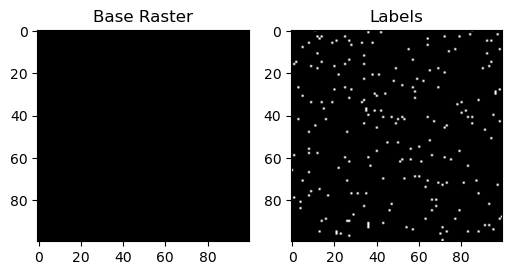

In [131]:
import rasterio
import matplotlib.pyplot as plt
from beak.utilities.file_io import read_raster_band

base_array, _ = read_raster_band(rasterio.open(os.path.join(data_folder, "base_raster.tif")))
labels_array, meta = read_raster_band(rasterio.open(os.path.join(data_folder, "label_raster.tif")))

# Plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3))
ax[0].imshow(base_array, cmap="gray")
ax[0].set_title("Base Raster")
ax[1].imshow(labels_array, cmap="gray")
ax[1].set_title("Labels")
plt.show()

## Extent positive labels

Creates buffer around **positive** labels in order to **extent** them and get more training labels.<br>
If no `buffer_value` is provided, the pixels within the buffer-zone will be set to the `positive_label_value`.


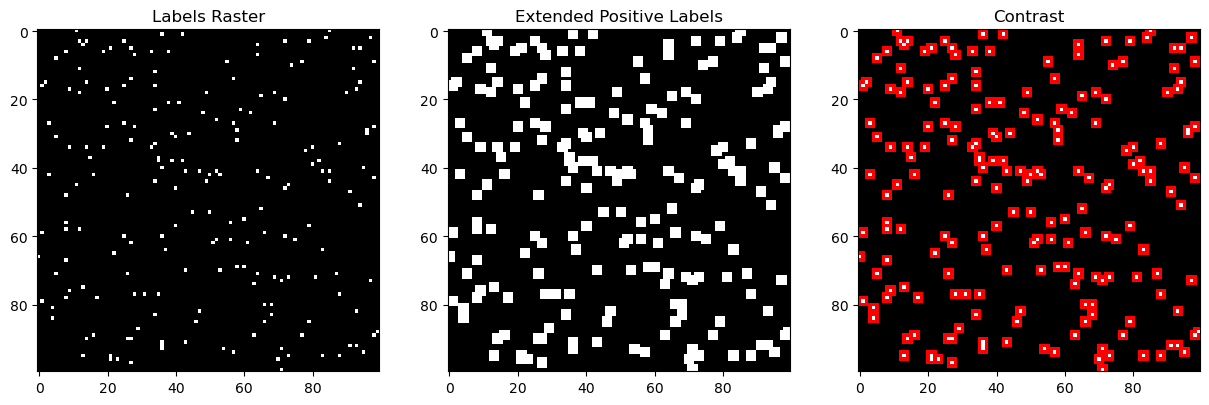

In [132]:
import numpy as np
from beak.experimental.preparation import create_hard_buffer_around_labels

# Create extended positive labels
extended_positives = create_hard_buffer_around_labels(labels_array,
                                                      radius=1,
                                                      shape="square",
                                                      target_value=1,
                                                      )

# Plot
fig_size = 5
ncols = 3

cmap = plt.cm.gray  # Start with the gray colormap
cmap.set_bad(color="red")

fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*fig_size,5))
ax[0].imshow(labels_array, cmap="gray")
ax[0].set_title("Labels Raster")
ax[1].imshow(extended_positives, cmap="gray")
ax[1].set_title("Extended Positive Labels")
ax[2].imshow(np.where(labels_array + extended_positives == 1, np.nan, extended_positives), cmap=cmap)
ax[2].set_title("Contrast")
plt.show()


In [133]:
# Compare original and extended labels
num_labels = np.unique(labels_array, return_counts=True)
num_extended_positives = np.unique(extended_positives, return_counts=True)

print(f"Original labels:\n{dict(zip(num_labels[0], num_labels[1]))}\n")
print(f"""Extended positive labels:\n{dict(zip(num_extended_positives[0], num_extended_positives[1]))}""")

Original labels:
{0.0: 9799, 1.0: 201}

Extended positive labels:
{0.0: 8336, 1.0: 1664}


In [134]:
# Save extended positive labels
from beak.utilities.file_io import save_raster, prepare_output

out_path = os.path.join(data_folder, "label_extended_positives.tif")
out_raster, out_meta = prepare_output(extended_positives, meta)
save_raster(out_raster, out_meta, out_path)

## Remove potential negative labels around positives
Remove potential **negatives** by buffering 2 pixels around the positive labels.<br>
The difference between this option and extending the positive labels is another `buffer_value` than the `positive_label_value`.<br>
Setting the buffered area to a value **different from 0 and 1** will remove the negative labels later on in the preprocessing.<br>

The `buffer_value` can be set to `np.nan`, since any rows containing `np.nan` will be removed before modeling, or another **number**.<br>
In both ways, they will not be considered in the workflow for modeling.<p>

Generally, setting the buffer value to `np.nan` or the specific `nodata` value based on the raster's metadata results in handling the results to be excluded in the workflow.<br>

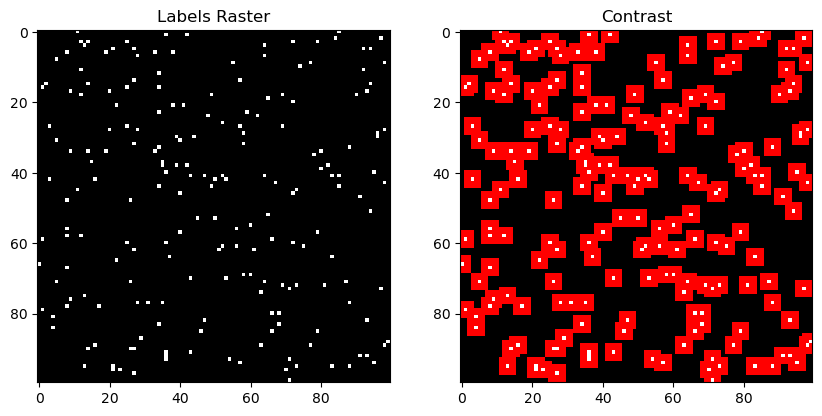

In [144]:
# Remove negative labels
removed_negatives = create_hard_buffer_around_labels(labels_array,
                                                     radius=2,
                                                     shape="square",
                                                     target_value=1,
                                                     buffer_value=np.nan,
                                                     )

# Plot
fig_size = 5
ncols = 2

cmap = plt.cm.gray  # Start with the gray colormap
cmap.set_bad(color="red")

fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*fig_size,5))
ax[0].imshow(labels_array, cmap="gray")
ax[0].set_title("Labels Raster")
ax[1].imshow(removed_negatives, cmap=cmap)
ax[1].set_title("Contrast")
plt.show()

In [136]:
# Compare original and extended labels
num_labels = np.unique(labels_array, return_counts=True)
num_removed_negatives = np.unique(removed_negatives, return_counts=True)

print(f"Original labels:\n{dict(zip(num_labels[0], num_labels[1]))}\n")
print(f"""Extended positive labels:\n{dict(zip(num_removed_negatives[0], num_removed_negatives[1]))}""")

Original labels:
{0.0: 9799, 1.0: 201}

Extended positive labels:
{0.0: 6071, 1.0: 201, nan: 3728}


In [137]:
# Save extended positive labels
from beak.utilities.file_io import save_raster, prepare_output

out_path = os.path.join(data_folder, "label_removed_negatives.tif")
out_raster, out_meta = prepare_output(removed_negatives, meta)
save_raster(out_raster, out_meta, out_path)

## Combination

1. Creates buffer around **positive** labels in order to **extent** them and get more training labels.<br>
2. Adds negative space around them to avoid that negative samples will be too close to positive samples.


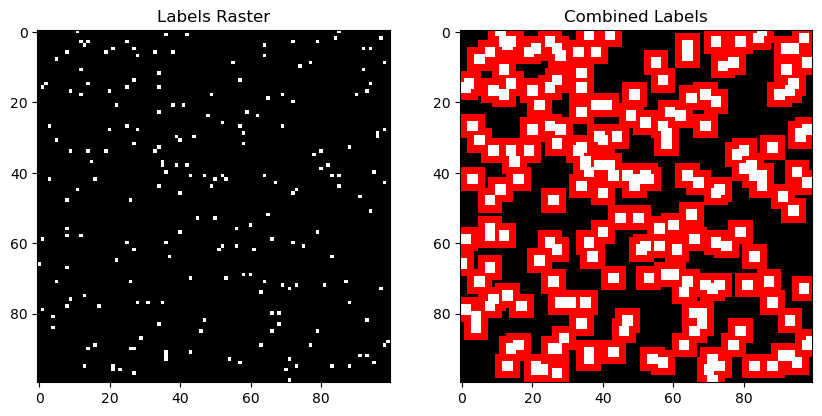

In [151]:
import numpy as np
from beak.experimental.preparation import create_hard_buffer_around_labels
from matplotlib.colors import ListedColormap

# Extend positives
extended_positives = create_hard_buffer_around_labels(labels_array,
                                                      radius=1,
                                                      shape="square",
                                                      target_value=1,
                                                      )

# Remove negative around positives
combined_labels = create_hard_buffer_around_labels(extended_positives,
                                                   radius=2,
                                                   shape="square",
                                                   target_value=1,
                                                   buffer_value=np.nan,
                                                   )

# Plot
fig_size = 5
ncols = 2

cmap = ListedColormap(["black", "white"])
cmap.set_bad(color="red")

fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*fig_size,5))
ax[0].imshow(labels_array, cmap="gray")
ax[0].set_title("Labels Raster")
ax[1].imshow(combined_labels, cmap=cmap)
ax[1].set_title("Combined Labels")
plt.show()


In [163]:
# Compare original and extended labels
num_labels = np.unique(labels_array, return_counts=True)
num_combined_labels = np.unique(combined_labels, return_counts=True)

print(f"Original labels:\n{dict(zip(num_labels[0], num_labels[1]))}\n")
print(f"Original labels:\n{dict(zip(num_combined_labels[0], num_combined_labels[1]))}\n")

Original labels:
{0.0: 9799, 1.0: 201}

Original labels:
{0.0: 3773, 1.0: 1664, nan: 4563}



In [164]:
# Save extended positive labels
from beak.utilities.file_io import save_raster, prepare_output

out_path = os.path.join(data_folder, "label_combined.tif")
out_raster, out_meta = prepare_output(combined_labels, meta)
save_raster(out_raster, out_meta, out_path)